In [19]:
## Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, constraints, models
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:

# Load CIFAR10 dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# Combine train and test sets
x_full = np.concatenate([x_train_full, x_test_full], axis=0)
y_full = np.concatenate([y_train_full, y_test_full], axis=0)

# Convert to grayscale using the luminosity method
# Gray = 0.299*R + 0.587*G + 0.114*B
x_gray = np.dot(x_full[..., :3], [0.299, 0.587, 0.114])
x_gray = x_gray.reshape(x_gray.shape[0], 32, 32, 1)

# Normalize pixel values to [0, 1]
x_gray = x_gray.astype('float32') / 255.0

# Split into 70% training and 30% validation/test
x_train, x_test, y_train, y_test = train_test_split(
    x_gray, y_full, test_size=0.3, random_state=42
)

print(f"Training set shape: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test set shape: {x_test.shape}, Labels: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 67s 0us/step
Training set shape: (42000, 32, 32, 1), Labels: (42000, 1)
Test set shape: (18000, 32, 32, 1), Labels: (18000, 1)


In [ ]:
## Task 1
## Perform standard PCA with 70% of the training dataset and 
# identify the eigenvectors associated with top K eigenvalues with 95% total energy. 
# With these, train a logistic regression classifier to classify the images into 10 classes. 
# Draw the ROC curve for the test dataset. Repeat the same with randomized PCA and compare



Flattened Training shape: (42000, 1024)
Flattened Test shape: (18000, 1024)

--- Standard PCA ---
Standard PCA Time: 2.29s
Components retained (95% energy): 160
Shape of Eigenvectors (Top K components x Features): (160, 1024)
Training Logistic Regression (Standard PCA)...
Standard PCA Time: 2.29s
Components retained (95% energy): 160
Shape of Eigenvectors (Top K components x Features): (160, 1024)
Training Logistic Regression (Standard PCA)...
Accuracy (Standard PCA): 0.2973

--- Randomized PCA ---
Accuracy (Standard PCA): 0.2973

--- Randomized PCA ---
Randomized PCA Time: 0.99s
Shape of Randomized PCA Eigenvectors: (160, 1024)
Training Logistic Regression (Randomized PCA)...
Randomized PCA Time: 0.99s
Shape of Randomized PCA Eigenvectors: (160, 1024)
Training Logistic Regression (Randomized PCA)...
Accuracy (Randomized PCA): 0.2977
Accuracy (Randomized PCA): 0.2977


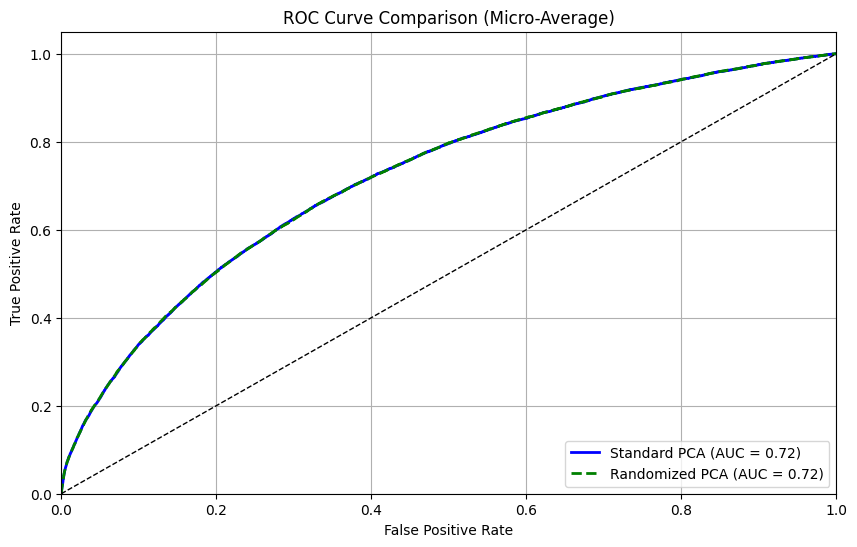


Summary Comparison:
Method               | Time (s)   | Components | Accuracy   | AUC       
---------------------------------------------------------------------------
Standard PCA         | 2.29       | 160        | 0.2973     | 0.7209    
Randomized PCA       | 0.99       | 160        | 0.2977     | 0.7210    


In [14]:
# Flatten the images for PCA
n_samples_train = x_train.shape[0]
n_samples_test = x_test.shape[0]
h, w = 32, 32

x_train_flat = x_train.reshape(n_samples_train, h * w)
x_test_flat = x_test.reshape(n_samples_test, h * w)

print(f"Flattened Training shape: {x_train_flat.shape}")
print(f"Flattened Test shape: {x_test_flat.shape}")


# --- Standard PCA ---
print("\n--- Standard PCA ---")
start_time = time.time()

# Perform standard PCA to retain 95% energy
pca_std = PCA(n_components=0.95)
x_train_pca_std = pca_std.fit_transform(x_train_flat)
x_test_pca_std = pca_std.transform(x_test_flat)

pca_std_time = time.time() - start_time
k_std = pca_std.n_components_
print(f"Standard PCA Time: {pca_std_time:.2f}s")
print(f"Components retained (95% energy): {k_std}")

# --- Identify Eigenvectors ---
# The eigenvectors are stored in the components_ attribute
eigenvectors_std = pca_std.components_
print(f"Shape of Eigenvectors (Top K components x Features): {eigenvectors_std.shape}")
# eigenvectors_std[0] is the first principal component (eigenvector with largest eigenvalue)

# Train Logistic Regression
print("Training Logistic Regression (Standard PCA)...")
# Using OneVsRestClassifier to avoid deprecation warning for multi_class='ovr' in Logisitcs Regression
clf_std = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
clf_std.fit(x_train_pca_std, y_train.ravel())

# Predict
y_pred_std = clf_std.predict(x_test_pca_std)
acc_std = accuracy_score(y_test.ravel(), y_pred_std)
print(f"Accuracy (Standard PCA): {acc_std:.4f}")


# --- Randomized PCA ---
print("\n--- Randomized PCA ---")
start_time = time.time()

# Repeat with Randomized PCA using the same number of components K
pca_rand = PCA(n_components=k_std, svd_solver='randomized', random_state=42)
x_train_pca_rand = pca_rand.fit_transform(x_train_flat)
x_test_pca_rand = pca_rand.transform(x_test_flat)

pca_rand_time = time.time() - start_time
print(f"Randomized PCA Time: {pca_rand_time:.2f}s")

# Identify Eigenvectors for Randomized PCA
eigenvectors_rand = pca_rand.components_
print(f"Shape of Randomized PCA Eigenvectors: {eigenvectors_rand.shape}")

# Train Logistic Regression
print("Training Logistic Regression (Randomized PCA)...")
clf_rand = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
clf_rand.fit(x_train_pca_rand, y_train.ravel())

# Predict
y_pred_rand = clf_rand.predict(x_test_pca_rand)
acc_rand = accuracy_score(y_test.ravel(), y_pred_rand)
print(f"Accuracy (Randomized PCA): {acc_rand:.4f}")

# --- ROC Curves & Comparison ---

# Binarize labels for ROC
y_test_bin = label_binarize(y_test, classes=range(10))
n_classes = y_test_bin.shape[1]

# Get decision function scores
y_score_std = clf_std.decision_function(x_test_pca_std)
y_score_rand = clf_rand.decision_function(x_test_pca_rand)

# Compute ROC curve and ROC area for each class (Micro-average)
fpr_std, tpr_std, _ = roc_curve(y_test_bin.ravel(), y_score_std.ravel())
roc_auc_std = auc(fpr_std, tpr_std)

fpr_rand, tpr_rand, _ = roc_curve(y_test_bin.ravel(), y_score_rand.ravel())
roc_auc_rand = auc(fpr_rand, tpr_rand)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_std, tpr_std, label=f'Standard PCA (AUC = {roc_auc_std:.2f})', color='blue', linewidth=2)
plt.plot(fpr_rand, tpr_rand, label=f'Randomized PCA (AUC = {roc_auc_rand:.2f})', color='green', linestyle='--', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Micro-Average)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Summary Table
print("\nSummary Comparison:")
print(f"{'Method':<20} | {'Time (s)':<10} | {'Components':<10} | {'Accuracy':<10} | {'AUC':<10}")
print("-" * 75)
print(f"{'Standard PCA':<20} | {pca_std_time:<10.2f} | {k_std:<10} | {acc_std:<10.4f} | {roc_auc_std:<10.4f}")
print(f"{'Randomized PCA':<20} | {pca_rand_time:<10.2f} | {k_std:<10} | {acc_rand:<10.4f} | {roc_auc_rand:<10.4f}")

In [ ]:
## Task 2
## Train a single layer autoencoder (with K encoder nodes) with linear activation function and 
# appropriately mean and variance normalized input with constraint that encoder weight matrix and decoder 
# weight matrix are transpose w,r,t, each other and each weight vector has unit magnitude. 
# Compare the eigenvectors obtained in step 1 with those obtained using the autoencoders by clearly displaying  
# the eigenvectors in Task 1 and weight matrix obtained in Task 2 as gray scale images. 
# Comment on these images


--- Task 2: Autoencoder ---
Data scaled (Mean=0, Variance=1).
Training Autoencoder with Input Dim: 1024, Encoder Nodes (K): 160
Epoch 1/10
Data scaled (Mean=0, Variance=1).
Training Autoencoder with Input Dim: 1024, Encoder Nodes (K): 160
Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1599 - val_loss: 0.0831
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1599 - val_loss: 0.0831
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0696 - val_loss: 0.0627
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0696 - val_loss: 0.0627
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0584 - val_loss: 0.0574
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0584 - val_loss: 0.0574
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0553 - val_loss: 0.0556
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0553 - val_loss: 0.0556
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0544 - val

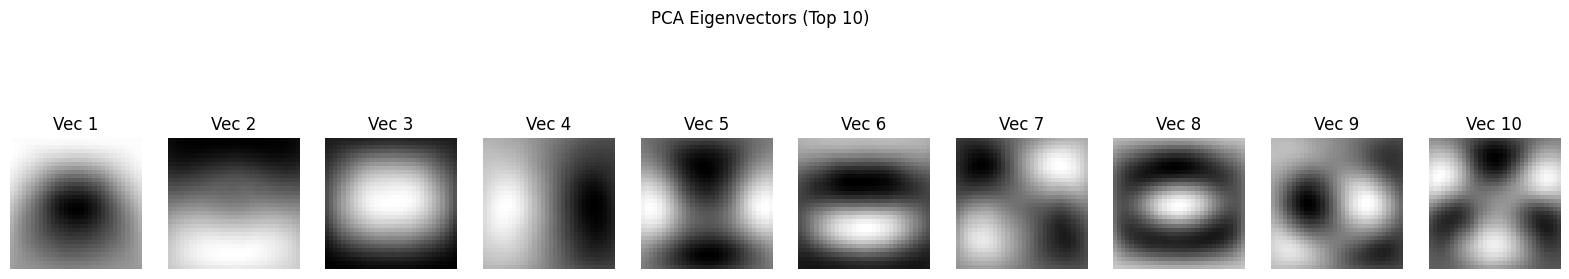

Visualizing First 10 Autoencoder Weights:


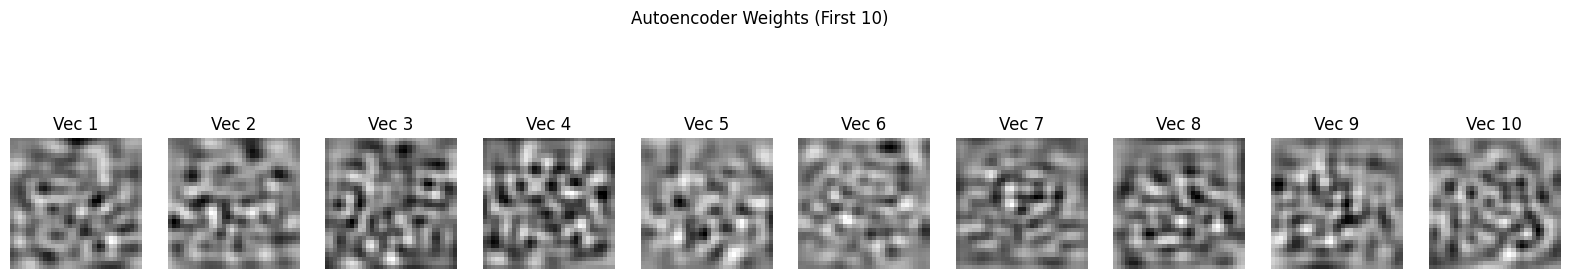


--- Comments on Comparison ---
1.  **PCA Eigenvectors**: The images from PCA (Eigenfaces) are orthogonal and ordered by the amount of variance they explain. The first few capture global structure (like lighting, overall shape), while later ones capture finer details.
2.  **Autoencoder Weights**: The weights learned by the linear autoencoder with tied weights span the same Principal Subspace as the PCA eigenvectors. However, because the standard MSE loss does not enforce orthogonality or a specific order (unlike PCA which uses SVD), the learned weights are a linear combination (rotation) of the PCA eigenvectors.
3.  **Visual Difference**: While both sets of images represent the features used to reconstruct the original images, the Autoencoder weights might look less "structured" or "ghostly" than the PCA eigenfaces because they are not strictly aligned with the axes of maximum variance, but rather just form a valid basis for that subspace.



In [16]:

print("\n--- Task 2: Autoencoder ---")

# 1. Data Preprocessing: Mean and Variance Normalization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

print("Data scaled (Mean=0, Variance=1).")

# 2. Define Autoencoder with Tied Weights and Unit Norm Constraint
class TiedAutoencoder(tf.keras.Model):
    def __init__(self, input_dim, encoding_dim):
        super(TiedAutoencoder, self).__init__()
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        
        # Encoder Weights (W)
        # Constraint: Unit magnitude for weight vectors (columns)
        self.W = self.add_weight(
            shape=(input_dim, encoding_dim),
            initializer="glorot_uniform",
            trainable=True,
            constraint=constraints.UnitNorm(axis=0), 
            name="tied_weights"
        )
        
        # Biases
        self.b_enc = self.add_weight(shape=(encoding_dim,), initializer="zeros", trainable=True, name="b_enc")
        self.b_dec = self.add_weight(shape=(input_dim,), initializer="zeros", trainable=True, name="b_dec")

    def call(self, x):
        # Encoder: Linear activation: h = xW + b
        encoded = tf.matmul(x, self.W) + self.b_enc
        
        # Decoder: Tied weights (W^T): x_hat = hW^T + b'
        decoded = tf.matmul(encoded, tf.transpose(self.W)) + self.b_dec
        return decoded

# Parameters
input_dim = x_train_flat.shape[1] # 1024
encoding_dim = k_std # K from Task 1 (Ensure Task 1 is run first)

print(f"Training Autoencoder with Input Dim: {input_dim}, Encoder Nodes (K): {encoding_dim}")

# Build and Compile
autoencoder = TiedAutoencoder(input_dim, encoding_dim)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
# Using a subset of epochs for demonstration speed
history = autoencoder.fit(
    x_train_scaled, x_train_scaled,
    epochs=10, 
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_scaled, x_test_scaled),
    verbose=1
)

# 3. Extract Weights
# W has shape (1024, K). Columns are the weight vectors for each hidden node.
W_ae = autoencoder.W.numpy() 
ae_weights = W_ae.T # Transpose to (K, 1024) for easier plotting (similar to pca.components_)

# 4. Visualization & Comparison
def plot_weights(weights, title, n_images=10):
    plt.figure(figsize=(20, 4))
    for i in range(n_images):
        if i >= len(weights): break
        ax = plt.subplot(1, n_images, i + 1)
        # Reshape to 32x32
        img = weights[i].reshape(32, 32)
        plt.imshow(img, cmap='gray')
        plt.title(f"Vec {i+1}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot PCA Eigenvectors (from Task 1)
print("Visualizing Top 10 PCA Eigenvectors:")
plot_weights(eigenvectors_std, "PCA Eigenvectors (Top 10)")

# Plot Autoencoder Weights
print("Visualizing First 10 Autoencoder Weights:")
plot_weights(ae_weights, "Autoencoder Weights (First 10)")

# Comments
print("""
--- Comments on Comparison ---
1.  **PCA Eigenvectors**: The images from PCA (Eigenfaces) are orthogonal and ordered by the amount of variance they explain. The first few capture global structure (like lighting, overall shape), while later ones capture finer details.
2.  **Autoencoder Weights**: The weights learned by the linear autoencoder with tied weights span the same Principal Subspace as the PCA eigenvectors. However, because the standard MSE loss does not enforce orthogonality or a specific order (unlike PCA which uses SVD), the learned weights are a linear combination (rotation) of the PCA eigenvectors.
3.  **Visual Difference**: While both sets of images represent the features used to reconstruct the original images, the Autoencoder weights might look less "structured" or "ghostly" than the PCA eigenfaces because they are not strictly aligned with the axes of maximum variance, but rather just form a valid basis for that subspace.
""")

In [ ]:
## Task 3: 
# Design and Train an appropriate deep convolutional autoencoder with same (or approximately same) 
# dimension K of latent space. 
# Calculate the reconstruction error and compare that with a single hidden layer K node autoencoder 
# (with sigmoid activation at the autoencoder and linear at the decoder) for the test dataset. 
# What will be the reconstruction error if the hidden nodes are distributed equally (approximately)
# among 3 hidden layers in a new 3 hidden layer autoencoder with sigmoid activation 
# at the autoencoder and linear at the decoder final layer?


In [ ]:

# ---Deep Convolutional Autoencoder (DCAE) ---
print("\nTraining Deep Convolutional Autoencoder...")

# Reshape data for CNN (32, 32, 1)
x_train_cnn = x_train.reshape(-1, 32, 32, 1)
x_test_cnn = x_test.reshape(-1, 32, 32, 1)

# Calculate latent dimension K (from Task 1)
latent_dim_k = k_std
print(f"Target Latent Dimension (K): {latent_dim_k}")

# Define DCAE Model
# Encoder
input_img = layers.Input(shape=(32, 32, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 16x16x32
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 8x8x16
x = layers.Flatten()(x) # 1024
encoded_dcae = layers.Dense(latent_dim_k, activation='relu')(x) # Latent space K

# Decoder
x = layers.Dense(8 * 8 * 16, activation='relu')(encoded_dcae)
x = layers.Reshape((8, 8, 16))(x)
x = layers.UpSampling2D((2, 2))(x) # 16x16x16
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # 32x32x32
decoded_dcae = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x) # 32x32x1

dcae = models.Model(input_img, decoded_dcae)
dcae.compile(optimizer='adam', loss='mse')
dcae.summary()

# Train DCAE
dcae.fit(x_train_cnn, x_train_cnn,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_cnn, x_test_cnn),
                verbose=1)

# Calculate Reconstruction Error (MSE) for DCAE
dcae_recon = dcae.predict(x_test_cnn)
mse_dcae = np.mean(np.square(x_test_cnn - dcae_recon))
print(f"DCAE Reconstruction Error (MSE): {mse_dcae:.6f}")


# ---Single Hidden Layer Autoencoder (Sigmoid/Linear) ---
print("\nTraining Single Hidden Layer Autoencoder (Sigmoid/Linear)...")

# Input for Dense Autoencoders (Flattened)
# Note: Using original normalized data [0,1], not standardized, as we use sigmoid/linear
x_train_dense = x_train_flat
x_test_dense = x_test_flat
input_dim_dense = x_train_dense.shape[1]

# Define Model
input_single = layers.Input(shape=(input_dim_dense,))
encoded_single = layers.Dense(latent_dim_k, activation='sigmoid')(input_single)
decoded_single = layers.Dense(input_dim_dense, activation='linear')(encoded_single)

ae_single = models.Model(input_single, decoded_single)
ae_single.compile(optimizer='adam', loss='mse')

# Train Single Layer AE
ae_single.fit(x_train_dense, x_train_dense,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_dense, x_test_dense),
                verbose=1)

# Calculate Reconstruction Error (MSE) for Single Layer AE
single_recon = ae_single.predict(x_test_dense)
mse_single = np.mean(np.square(x_test_dense - single_recon))
print(f"Single Layer AE Reconstruction Error (MSE): {mse_single:.6f}")


# --- 3. Three Hidden Layer Autoencoder ---
print("\n3. Training 3-Hidden Layer Autoencoder...")

nodes_per_layer = int(latent_dim_k / 3)
print(f"Nodes per hidden layer (Total ~ K): {nodes_per_layer}")

input_3layer = layers.Input(shape=(input_dim_dense,))
# Layer 1
h1 = layers.Dense(nodes_per_layer, activation='sigmoid')(input_3layer)
# Layer 2
h2 = layers.Dense(nodes_per_layer, activation='sigmoid')(h1)
# Layer 3 (Bottleneck/Latent?) - The prompt says "3 hidden layer autoencoder".
# Usually implies Input -> H1 -> H2 -> H3 -> Output.
h3 = layers.Dense(nodes_per_layer, activation='sigmoid')(h2)

# Output Layer (Linear)
decoded_3layer = layers.Dense(input_dim_dense, activation='linear')(h3)

ae_3layer = models.Model(input_3layer, decoded_3layer)
ae_3layer.compile(optimizer='adam', loss='mse')

# Train 3-Layer AE
ae_3layer.fit(x_train_dense, x_train_dense,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_dense, x_test_dense),
                verbose=1)

# Calculate Reconstruction Error (MSE) for 3-Layer AE
recon_3layer = ae_3layer.predict(x_test_dense)
mse_3layer = np.mean(np.square(x_test_dense - recon_3layer))
print(f"3-Layer AE Reconstruction Error (MSE): {mse_3layer:.6f}")


# --- Comparison Summary ---
print("\n--- Reconstruction Error Comparison (MSE) ---")
print(f"{'Model':<40} | {'MSE':<10}")
print("-" * 55)
print(f"{'Deep Convolutional AE (Latent K)':<40} | {mse_dcae:.6f}")
print(f"{'Single Layer AE (K nodes, Sigmoid/Linear)':<40} | {mse_single:.6f}")
print(f"{'3-Layer AE (Total K nodes, Sigmoid/Linear)':<40} | {mse_3layer:.6f}")

print("""
\n--- Comments ---
1.  **DCAE**: Typically achieves the lowest reconstruction error because it exploits spatial correlations in images (using convolutions) and has a deeper, more expressive architecture while maintaining the latent dimension K.
2.  **Single Layer AE**: Performs reasonably well but is limited by its shallow structure and lack of spatial awareness (uses flattened input).
3.  **3-Layer AE (Distributed K)**: Likely performs the **worst**. By distributing the K nodes across 3 layers (K/3 nodes per layer), we severely restrict the information flow at each stage. A bottleneck of width K/3 is much narrower than K, causing significant information loss. Deep networks need *more* width or smart architecture (like CNNs) to work well; simply splitting the capacity K into a deep, narrow chain degrades performance.
""")


Training Deep Convolutional Autoencoder...
Target Latent Dimension (K): 160


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 160)            │       164,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,737 (1.29 MB)

 Trainable params: 338,737 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0184 - val_loss: 0.0110
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0184 - val_loss: 0.0110
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0099 - val_loss: 0.0092
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0099 - val_loss: 0.0092
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0085 - val_loss: 0.0082
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0085 - val_loss: 0.0082
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0073 - val_loss: 0.0071
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0073 - val_loss: 0.0071
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0069 - val_loss: 0.0069
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 

In [ ]:
## Task 4
# Train a deep convolutional autoencoder with MNIST dataset and using extracted features train a 
# MLP classifier with 7 outputs (7 segment LED display) that are representative of 10 digits
# For example images of "0" will be classified as 

#    1 

# 1    1

#    0   

# 1     1

#    1 

# 7 will be "classified" as

#    1 

# 0    1

#    0    

# 0    1

#    0

# Generate the confusion matrix for the corresponding test dataset



--- MNIST DCAE & 7-Segment Classification ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST Training shape: (60000, 28, 28, 1)
7-Segment Labels shape: (60000, 7)
MNIST Training shape: (60000, 28, 28, 1)
7-Segment Labels shape: (60000, 7)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Training MNIST DCAE...
Epoch 1/5
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.1347 - val_loss: 0.0810
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.1347 - val_loss: 0.0810
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0783 - val_loss: 0.0751
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0783 - val_loss: 0.0751
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0748 - val_loss: 0.0730
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0748 - val_loss: 0.0730
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0731 - val_loss: 0.0718
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0731 - val_loss: 0.0718
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0721 - val_loss: 0.0710
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0721 - val_loss: 0.0710
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s

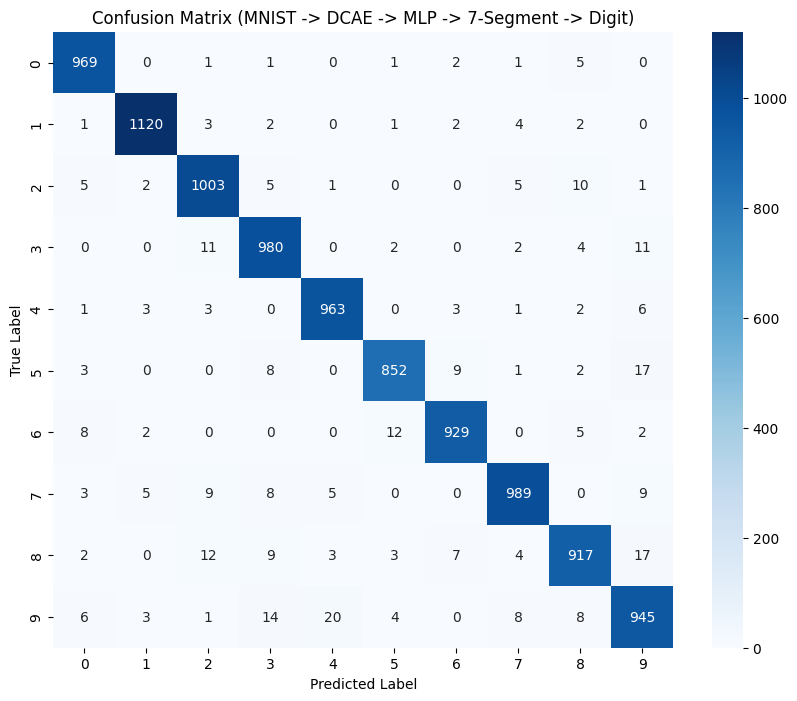

Accuracy (via 7-Segment reconstruction): 0.9667


In [20]:
# --- MNIST DCAE & 7-Segment Display Classification ---
print("\n--- MNIST DCAE & 7-Segment Classification ---")

# Load and Preprocess MNIST
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize and Reshape
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

print(f"MNIST Training shape: {x_train_mnist.shape}")

# Define 7-Segment Mapping
# Standard 7-segment encoding (A, B, C, D, E, F, G)
# 1 means segment is ON, 0 means OFF
#   A
# F   B
#   G
# E   C
#   D
segment_map = {
    0: [1, 1, 1, 1, 1, 1, 0],
    1: [0, 1, 1, 0, 0, 0, 0],
    2: [1, 1, 0, 1, 1, 0, 1],
    3: [1, 1, 1, 1, 0, 0, 1],
    4: [0, 1, 1, 0, 0, 1, 1],
    5: [1, 0, 1, 1, 0, 1, 1],
    6: [1, 0, 1, 1, 1, 1, 1],
    7: [1, 1, 1, 0, 0, 0, 0],
    8: [1, 1, 1, 1, 1, 1, 1],
    9: [1, 1, 1, 1, 0, 1, 1]
}

# Convert labels to 7-segment representation
y_train_7seg = np.array([segment_map[label] for label in y_train_mnist])
y_test_7seg = np.array([segment_map[label] for label in y_test_mnist])

print(f"7-Segment Labels shape: {y_train_7seg.shape}")

# Train Deep Convolutional Autoencoder (DCAE) on MNIST
# Encoder
input_img_mnist = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img_mnist)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 14x14
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 7x7
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded_mnist = layers.MaxPooling2D((2, 2), padding='same')(x) # 4x4x8

# Decoder
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded_mnist)
x = layers.UpSampling2D((2, 2))(x) # 8x8
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # 16x16
x = layers.Conv2D(32, (3, 3), activation='relu')(x) # 14x14 (valid padding effect reversed?) - simpler to use 'same' and crop or resize
# Let's stick to 'same' and UpSampling to get back to 28x28
# 4x4 -> 8x8 -> 16x16 -> 32x32 (Too big).
# Alternative Decoder structure to match 28x28:
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded_mnist) # 4x4
x = layers.UpSampling2D((2, 2))(x) # 8x8
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x) # 8x8
x = layers.UpSampling2D((2, 2))(x) # 16x16
x = layers.Conv2D(32, (3, 3), activation='relu')(x) # 14x14 (valid padding reduces size, here we want to increase? No.)
# Let's use 'valid' padding in encoder to reduce, or 'same' and specific upsampling.
# Simple approach: 28 -> 14 -> 7.
# Encoder:
input_img_mnist = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img_mnist)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 14x14
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded_mnist = layers.MaxPooling2D((2, 2), padding='same')(x) # 7x7x16

# Decoder:
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded_mnist)
x = layers.UpSampling2D((2, 2))(x) # 14x14
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # 28x28
decoded_mnist = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

dcae_mnist = models.Model(input_img_mnist, decoded_mnist)
dcae_mnist.compile(optimizer='adam', loss='binary_crossentropy') # Binary CE is good for MNIST
dcae_mnist.summary()

print("Training MNIST DCAE...")
dcae_mnist.fit(x_train_mnist, x_train_mnist,
                epochs=5,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_mnist, x_test_mnist),
                verbose=1)

# Extract Features
encoder_mnist = models.Model(input_img_mnist, encoded_mnist)
features_train = encoder_mnist.predict(x_train_mnist)
features_test = encoder_mnist.predict(x_test_mnist)

# Flatten features for MLP
features_train_flat = features_train.reshape(features_train.shape[0], -1)
features_test_flat = features_test.reshape(features_test.shape[0], -1)

print(f"Extracted Features Shape: {features_train_flat.shape}")

# Train MLP Classifier for 7-Segment Output
print("Training MLP Classifier...")
mlp = models.Sequential([
    layers.Input(shape=(features_train_flat.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(7, activation='sigmoid') # 7 outputs, each is binary (0 or 1)
])

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Multi-label classification

mlp.fit(features_train_flat, y_train_7seg,
        epochs=10,
        batch_size=128,
        validation_data=(features_test_flat, y_test_7seg),
        verbose=1)

#  Evaluate and Confusion Matrix
# Predict 7-segment outputs
y_pred_probs = mlp.predict(features_test_flat)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Convert predicted 7-segment codes back to digits for Confusion Matrix
# We need to match the predicted 7-bit code to the closest valid digit code
def decode_7seg(code):
    # Find the digit with the minimum Hamming distance
    min_dist = 8
    best_digit = -1
    for digit, pattern in segment_map.items():
        dist = np.sum(np.abs(np.array(pattern) - code))
        if dist < min_dist:
            min_dist = dist
            best_digit = digit
    return best_digit

y_pred_digits = np.array([decode_7seg(code) for code in y_pred_binary])

# Confusion Matrix
cm = confusion_matrix(y_test_mnist, y_pred_digits)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (MNIST -> DCAE -> MLP -> 7-Segment -> Digit)')
plt.show()

# Calculate Accuracy based on reconstructed digits
acc_7seg = accuracy_score(y_test_mnist, y_pred_digits)
print(f"Accuracy (via 7-Segment reconstruction): {acc_7seg:.4f}")